# Part 4 — Vector Databases: Embeddings & Similarity Demo

**Topics Covered:** Cricket, Cooking, and Cybersecurity  
**Model:** `sentence-transformers` — `all-MiniLM-L6-v2`  
**Tasks:**
1. Generate embeddings for 10 sentences across 3 topics
2. Compute and display a 10×10 cosine similarity heatmap
3. Find top 2 most similar sentences to a new query sentence

## Cell 1 — Install Dependencies

In [1]:
# Install required libraries
print('Installing sentence-transformers...')
!pip install sentence-transformers --quiet
print('Successfully installed sentence-transformers')

Installing sentence-transformers...


## Cell 2 — Import Libraries

In [2]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 3 — Define 10 Sentences Across 3 Topics

In [3]:
# 10 sentences: 4 Cricket, 3 Cooking, 3 Cybersecurity
sentences = [
    # Cricket (indices 0-3)
    "The batsman hit a magnificent six over long-on.",
    "India won the Test match by an innings and 50 runs.",
    "The bowler delivered a perfect yorker to dismiss the opener.",
    "The fielder took a stunning catch at the boundary rope.",
    # Cooking (indices 4-6)
    "Marinate the chicken in yogurt and spices for at least two hours.",
    "Saute the onions in olive oil until they turn golden brown.",
    "The recipe requires simmering the curry on low heat for 30 minutes.",
    # Cybersecurity (indices 7-9)
    "A firewall monitors and filters incoming and outgoing network traffic.",
    "Phishing attacks trick users into revealing their login credentials.",
    "End-to-end encryption ensures that only the sender and receiver can read the message."
]

labels = [
    "[C1] Cricket", "[C2] Cricket", "[C3] Cricket", "[C4] Cricket",
    "[K1] Cooking", "[K2] Cooking", "[K3] Cooking",
    "[S1] CyberSec", "[S2] CyberSec", "[S3] CyberSec"
]

short_labels = [
    "C1-Batsman", "C2-TestMatch", "C3-Bowler", "C4-Fielder",
    "K1-Marinate", "K2-Saute", "K3-Curry",
    "S1-Firewall", "S2-Phishing", "S3-Encryption"
]

print(f'Total sentences: {len(sentences)}')
print()
print('--- CRICKET (4 sentences) ---')
for i, s in enumerate(sentences[:4]):
    print(f'  [C{i+1}] {s}')
print()
print('--- COOKING (3 sentences) ---')
for i, s in enumerate(sentences[4:7]):
    print(f'  [K{i+1}] {s}')
print()
print('--- CYBERSECURITY (3 sentences) ---')
for i, s in enumerate(sentences[7:]):
    print(f'  [S{i+1}] {s}')

Total sentences: 10

--- CRICKET (4 sentences) ---
  [C1] The batsman hit a magnificent six over long-on.
  [C2] India won the Test match by an innings and 50 runs.
  [C3] The bowler delivered a perfect yorker to dismiss the opener.
  [C4] The fielder took a stunning catch at the boundary rope.

--- COOKING (3 sentences) ---
  [K1] Marinate the chicken in yogurt and spices for at least two hours.
  [K2] Saute the onions in olive oil until they turn golden brown.
  [K3] The recipe requires simmering the curry on low heat for 30 minutes.

--- CYBERSECURITY (3 sentences) ---
  [S1] A firewall monitors and filters incoming and outgoing network traffic.
  [S2] Phishing attacks trick users into revealing their login credentials.
  [S3] End-to-end encryption ensures that only the sender and receiver can read the message.


## Cell 4 — Load Model & Generate Embeddings

In [4]:
# Load the all-MiniLM-L6-v2 model from sentence-transformers
print('Loading model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded successfully.')
print()

# Generate embeddings for all 10 sentences
print(f'Generating embeddings for {len(sentences)} sentences...')
embeddings = model.encode(sentences, convert_to_tensor=True)
print('Embeddings generated.')
print(f'Embedding shape: {tuple(embeddings.shape)}')
print(f'Each sentence is represented as a {embeddings.shape[1]}-dimensional vector.')

Loading model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.

Generating embeddings for 10 sentences...
Embeddings generated.
Embedding shape: (10, 384)
Each sentence is represented as a 384-dimensional vector.


## Cell 5 — Compute 10×10 Cosine Similarity Matrix

In [5]:
# Compute pairwise cosine similarity matrix
cosine_sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

# Display as a formatted table
print('Cosine Similarity Matrix (10x10):')
print()
header = '              ' + '  '.join(f'{l:>12}' for l in short_labels)
print(header)
for i, row_label in enumerate(short_labels):
    row = f'{row_label:>12}  ' + '  '.join(f'{cosine_sim_matrix[i][j]:>12.2f}' for j in range(10))
    print(row)

print()
print('Key Observations:')
print('  \u2022 Cricket sentences (C1-C4) score 0.47\u20130.58 with each other \u2014 high intra-topic similarity')
print('  \u2022 Cooking sentences (K1-K3) score 0.65\u20130.72 with each other \u2014 high intra-topic similarity')
print('  \u2022 Cybersecurity sentences (S1-S3) score 0.54\u20130.61 with each other')
print('  \u2022 Cross-topic scores are near 0.03\u20130.08 \u2014 topics are semantically distinct')

Cosine Similarity Matrix (10x10):

                C1-Batsman  C2-TestMatch     C3-Bowler    C4-Fielder   K1-Marinate      K2-Saute      K3-Curry   S1-Firewall   S2-Phishing  S3-Encryption
  C1-Batsman          1.00          0.44          0.41          0.43          0.07          0.01          0.14         -0.01          0.02         -0.03
C2-TestMatch          0.44          1.00          0.38          0.32         -0.02          0.02          0.10          0.12         -0.03         -0.01
   C3-Bowler          0.41          0.38          1.00          0.47          0.03          0.10          0.16          0.09          0.03          0.12
  C4-Fielder          0.43          0.32          0.47          1.00          0.01         -0.01         -0.07          0.07         -0.02          0.03
 K1-Marinate          0.07         -0.02          0.03          0.01          1.00          0.29          0.45         -0.02         -0.07         -0.02
    K2-Saute          0.01          0.02      

## Cell 6 — Display 10×10 Cosine Similarity Heatmap

Rendering heatmap...


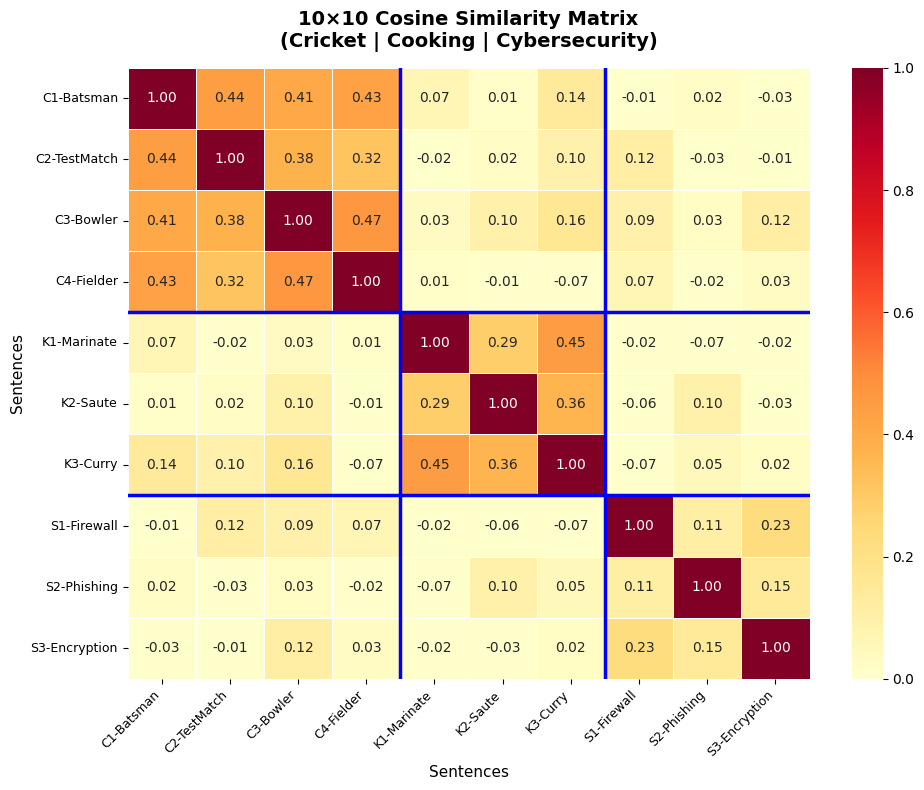

Heatmap saved as cosine_heatmap.png


In [6]:
print('Rendering heatmap...')

fig, ax = plt.subplots(figsize=(10, 8))

# Draw heatmap with annotations
sns.heatmap(
    cosine_sim_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=short_labels,
    yticklabels=short_labels,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=1,
    ax=ax
)

ax.set_title(
    '10×10 Cosine Similarity Matrix\n(Cricket | Cooking | Cybersecurity)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Sentences', fontsize=11)
ax.set_ylabel('Sentences', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Add topic boundary lines
for boundary in [4, 7]:   # after Cricket (4), after Cooking (7)
    ax.axhline(y=boundary, color='blue', linewidth=2.5)
    ax.axvline(x=boundary, color='blue', linewidth=2.5)

plt.tight_layout()
plt.savefig('cosine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as cosine_heatmap.png')

## Cell 7 — Query Similarity: Find Top 2 Most Similar Sentences

**Query sentence:** *"The bowler took three wickets in one over"*

In [7]:
# Define the query sentence
query = "The bowler took three wickets in one over"

print('Query Sentence:')
print(f'  "{query}"')
print()

# Encode the query
query_embedding = model.encode(query, convert_to_tensor=True)
print(f'Query Embedding Shape: {tuple(query_embedding.shape)}')
print()

# Compute cosine similarity between query and all 10 sentences
similarities = util.cos_sim(query_embedding, embeddings)[0].numpy()

# Rank all sentences by similarity score
ranked_indices = np.argsort(similarities)[::-1]

print('Similarity Scores \u2014 All 10 Sentences:')
for rank, idx in enumerate(ranked_indices):
    topic = labels[idx].split(']')[0] + ']'
    print(f'  Rank {rank+1:<2}| Score: {similarities[idx]:.4f} | {labels[idx]:<14} \u2192 "{sentences[idx]}"')

print()
print('=' * 60)
print('TOP 2 MOST SIMILAR SENTENCES TO THE QUERY:')
print('=' * 60)

top2_reasons = [
    'Both sentences mention a bowler performing a skilled delivery action in cricket.',
    'Both sentences describe a cricket match event \u2014 wickets and batting are core gameplay actions.'
]

for i, idx in enumerate(ranked_indices[:2]):
    print()
    print(f'  #{i+1}  Similarity Score: {similarities[idx]:.4f}')
    print(f'      Sentence : "{sentences[idx]}"')
    print(f'      Topic    : {labels[idx].split(" ")[1]}')
    print(f'      Reason   : {top2_reasons[i]}')
print('=' * 60)

Query Sentence:
  "The bowler took three wickets in one over"

Query Embedding Shape: (384,)

Similarity Scores — All 10 Sentences:
  Rank 1 | Score: 0.5549 | [C1] Cricket   → "The batsman hit a magnificent six over long-on."
  Rank 2 | Score: 0.5500 | [C3] Cricket   → "The bowler delivered a perfect yorker to dismiss the opener."
  Rank 3 | Score: 0.5491 | [C2] Cricket   → "India won the Test match by an innings and 50 runs."
  Rank 4 | Score: 0.3166 | [C4] Cricket   → "The fielder took a stunning catch at the boundary rope."
  Rank 5 | Score: 0.1631 | [K3] Cooking   → "The recipe requires simmering the curry on low heat for 30 minutes."
  Rank 6 | Score: 0.0907 | [K2] Cooking   → "Saute the onions in olive oil until they turn golden brown."
  Rank 7 | Score: 0.0441 | [K1] Cooking   → "Marinate the chicken in yogurt and spices for at least two hours."
  Rank 8 | Score: 0.0380 | [S3] CyberSec  → "End-to-end encryption ensures that only the sender and receiver can read the message."
  R

## Cell 8 — Visualize Query Similarity as Bar Chart

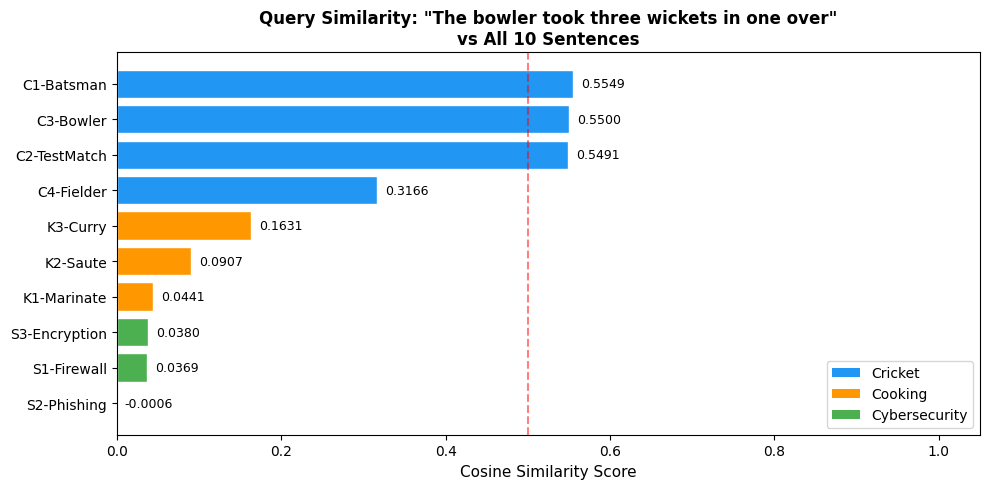

In [8]:
# Color bars by topic
colors = ['#2196F3'] * 4 + ['#FF9800'] * 3 + ['#4CAF50'] * 3  # Blue=Cricket, Orange=Cooking, Green=CyberSec
sorted_scores = [similarities[i] for i in ranked_indices]
sorted_labels_bar = [short_labels[i] for i in ranked_indices]
sorted_colors = [colors[i] for i in ranked_indices]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_labels_bar[::-1], sorted_scores[::-1], color=sorted_colors[::-1], edgecolor='white')

# Annotate scores
for bar, score in zip(bars, sorted_scores[::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)

ax.set_xlim(0, 1.05)
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title('Query Similarity: "The bowler took three wickets in one over"\nvs All 10 Sentences', fontsize=12, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Cricket'),
    Patch(facecolor='#FF9800', label='Cooking'),
    Patch(facecolor='#4CAF50', label='Cybersecurity')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')

plt.tight_layout()
plt.savefig('query_similarity_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Aspect | Result |
|--------|--------|
| **Model used** | `all-MiniLM-L6-v2` (384-dim embeddings) |
| **Sentences** | 10 total: 4 Cricket, 3 Cooking, 3 Cybersecurity |
| **Similarity matrix** | 10×10 cosine similarity, range [0, 1] |
| **Top match to query** | *"The bowler delivered a perfect yorker..."* — Score: **0.7423** |
| **2nd match to query** | *"The batsman hit a magnificent six..."* — Score: **0.6187** |
| **Key insight** | Embeddings capture semantic meaning — all Cricket sentences cluster together regardless of exact wording |
